In [1]:
import pcdl
import numpy as np
from numpy.linalg import norm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

/home/vincent/.local/share/mamba/envs/certainty/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/vincent/.local/share/mamba/envs/certainty/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/home/vincent/.local/share/mamba/envs/certainty/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to p

In [2]:
mcdsts = pcdl.TimeSeries('output/', verbose=False)

In [3]:
data = mcdsts.get_cell_df()

In [4]:
# list(data.columns)

In [5]:
data = data.loc[:, ['ID', 'time', 'position_x', 'position_y', 'position_z', 'cell_type']]

In [6]:
ids = list(set(data.loc[:, 'ID']))
times = sorted(list(set(data.loc[:, 'time'])))
time_tick = times[1] - times[0]

In [7]:
print(f"Simulation loaded: {len(ids)} cells, {len(times)} timepoints")

Simulation loaded: 700 cells, 241 timepoints


In [8]:
from track_metrics import calc_turning_angle, calculate_spatial_coverage, compute_msd, compute_displacement_autocorrelation
from plotting import plot_grouped_data

In [9]:
## Calculate displacements if necessary
data = data.sort_values(['ID', 'time'])
if 'Displacement X' not in data.columns:
    data['Displacement X'] = data.groupby('ID')['position_x'].diff()
if 'Displacement Y' not in data.columns:
    data['Displacement Y'] = data.groupby('ID')['position_y'].diff()
if 'Displacement Z' not in data.columns:
    data['Displacement Z'] = data.groupby('ID')['position_z'].diff()
# Calculate displacement vector length
data['Displacement_vector_length'] = np.sqrt(
    data['Displacement X']**2 +
    data['Displacement Y']**2 +
    data['Displacement Z']**2
)
# Calculate turning angle
data['Turning_angle_radians'] = data.groupby('ID', group_keys=False).apply(lambda g: calc_turning_angle(
    g['Displacement X'],
    g['Displacement Y'],
    g['Displacement Z'])
    )
data['Turning_angle_degrees'] = data['Turning_angle_radians']/ np.pi * 180 # Convert to degrees



In [10]:
## Calculate spatial coverage for all tracks
if 'Spatial Coverage' not in data.columns:
    df_tmp = data.groupby('ID').apply(lambda g: calculate_spatial_coverage(g, var_names=['time', 'position_x', 'position_y', 'position_z'])).reset_index()
    ## Integrate result into df_data_track
    data = pd.merge(data, df_tmp[['ID', 'Spatial Coverage']], on='ID')

In [11]:
# Turning angle
if 'Total Turning Angle' not in data.columns:
    df_tmp = data.groupby('ID').apply( lambda x: np.sum(x['Turning_angle_radians']) ).reset_index(name='Total Turning Angle')
    ## Integrate result into df_data_track
    data = pd.merge(data, df_tmp[['ID', 'Total Turning Angle']], on='ID')


In [12]:
data.head(3)

,ID,time,position_x,position_y,position_z,cell_type,Displacement X,Displacement Y,Displacement Z,Displacement_vector_length,Turning_angle_radians,Turning_angle_degrees,Spatial Coverage,Total Turning Angle
0,0,0.0,-379.780917,-486.428302,0.0,Plasma,NaN,NaN,NaN,NaN,NaN,NaN,0.000004,7.315268
1,0,60.0,-382.589471,-487.202844,0.0,Plasma,-2.808554,-0.774541,0.0,2.913398,NaN,NaN,0.000004,7.315268
2,0,120.0,-380.806144,-492.931696,0.0,Plasma,1.783327,-5.728852,0.0,6.000000,1.603487,91.873014,0.000004,7.315268


array([<Axes: title={'center': 'cell_type: Plasma'}, xlabel='time', ylabel='msd'>,
       <Axes: title={'center': 'cell_type: TCell'}, xlabel='time', ylabel='msd'>,
       <Axes: >, <Axes: >], dtype=object)

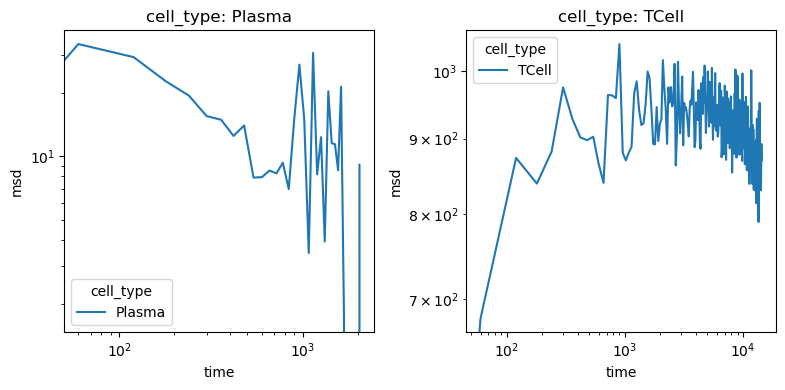

In [13]:
condition_vars = ['cell_type']
msd_all = compute_msd(data, condition_vars, time_frame_col='time', displacement_col='Displacement_vector_length')

# Plot MSD
plot_grouped_data(msd_all, plot_var='msd', group_var='cell_type', hue_var='cell_type', plot_type='msd', x_var='time')

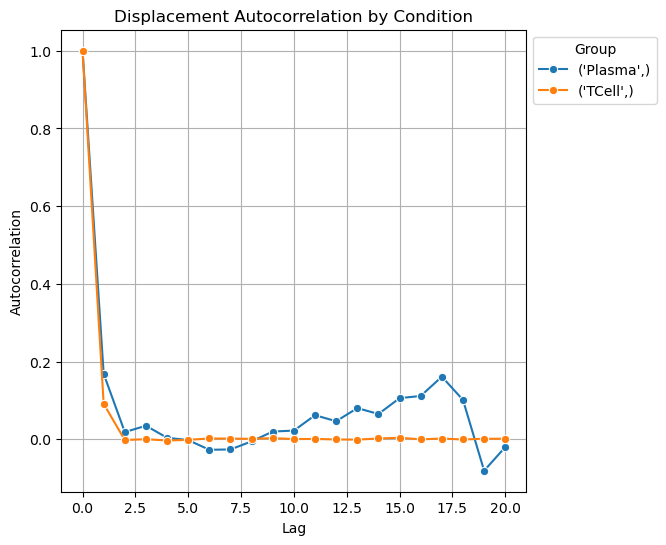

In [14]:
## Compute autocorrelation and plot
# Specify conditions to compare
data_copy = data.copy()
# data['Condition'] = data['Well'] + '_' + data['Channel'] 
condition_vars = ['cell_type']
# autocorr_df = compute_displacement_autocorrelation(data, condition_col='Condition', max_lag=20)
autocorr_df = compute_displacement_autocorrelation(data_copy, condition_vars, max_lag=20)

# Plot results
_, ax = plt.subplots(figsize=(6, 6))
sns.lineplot(data=autocorr_df, x='Lag', y='Autocorrelation', hue='Group', marker='o', ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Displacement Autocorrelation by Condition")
plt.grid(True)
plt.show()


In [15]:
## Fit the autocorrelation function to an exponential decay model
from scipy.optimize import curve_fit
def exp_decay(tau, tau_p):
        return np.exp(-tau / tau_p)

def fit_autocorr(autocorr, verbose=True):
    lags = np.arange(len(autocorr))

    # Use only finite values and exclude NaNs or early noise if needed
    valid = np.isfinite(autocorr) & (lags > 0)  # optionally skip lag 0 if it's noisy
    popt, pcov = curve_fit(exp_decay, lags[valid], autocorr[valid], p0=(5.0))

    tau_p_fit = popt[0]

    if verbose:
        print(f"Fitted parameters: {popt}")
        print(f"Covariance of parameters: {pcov}")
        print(f"Estimated persistence time τ_p = {tau_p_fit}")
    
    return tau_p_fit

def fit_msd(times, msd_values, tau_p, d = 3, verbose=True):
    """
    Fit the MSD data to Furth's formula.
    Parameters:
    - msd_values: Array of MSD values.
    - times: Array of time steps.
    - tau_p: Estimated persistence time.
    Returns:
    - D_fit: Estimated diffusion constant.
    """

    def msd_prw(tau, D): # Furth's formula
        return 2*d*D*(tau - tau_p*(1 - np.exp(-tau / tau_p)))

    # Use only finite values and exclude NaNs or early noise if needed
    valid = np.isfinite(msd_values) & (times > 0)  # optionally skip lag 0 if it's noisy
    popt, pcov = curve_fit(msd_prw, times[valid], msd_values[valid], p0=(5.0))

    D_fit = popt[0]
    if verbose:
        print(f"Fitted parameters: {popt}")
        print(f"Covariance of parameters: {pcov}")
        print(f"Estimated diffusion constant D = {D_fit}")

    return D_fit




Apply fit


In [16]:


## Apply the fit to the autocorrelation data
# Single example
# autocorr = autocorr_df.loc[autocorr_df['Condition']=='CD4', 'Autocorrelation'].values # .copy()
# tau_p_fit = fit_autocorr(autocorr)

# All conditions
tau_p_fit_all = autocorr_df.groupby('Group')['Autocorrelation'].apply(lambda x: fit_autocorr(x.values)).reset_index(name='tau_p') 
tau_p_fit_all.head()

Fitted parameters: [0.55972979]
Covariance of parameters: [[0.01425323]]
Estimated persistence time τ_p = 0.5597297949515323
Fitted parameters: [0.41378421]
Covariance of parameters: [[3.03620466e-05]]
Estimated persistence time τ_p = 0.4137842072232086


,Group,tau_p
0,"(Plasma,)",0.559730
1,"(TCell,)",0.413784


In [17]:
# Merged fitted tau_p data into msd_all
msd_all['Group'] = list(zip(msd_all['cell_type']))
if 'tau_p' not in msd_all.columns:
    # Just merge normally if tau_p doesn't exist
    msd_all = pd.merge(msd_all, tau_p_fit_all[['Group', 'tau_p']], on='Group', how='left')
else:
    # Update tau_p column from tau_p_fit_all
    msd_all = msd_all.drop(columns=['tau_p'])  # optional: drop old one first
    msd_all = pd.merge(msd_all, tau_p_fit_all[['Group', 'tau_p']], on='Group', how='left')
msd_all

,cell_type,time,msd,Group,tau_p
0,Plasma,0.0,0.000000,"(Plasma,)",0.559730
1,Plasma,60.0,33.945046,"(Plasma,)",0.559730
2,Plasma,120.0,29.424642,"(Plasma,)",0.559730
3,Plasma,180.0,22.592580,"(Plasma,)",0.559730
4,Plasma,240.0,19.340584,"(Plasma,)",0.559730
...,...,...,...,...,...
271,TCell,14160.0,854.862458,"(TCell,)",0.413784
272,TCell,14220.0,829.958411,"(TCell,)",0.413784
273,TCell,14280.0,863.587667,"(TCell,)",0.413784
274,TCell,14340.0,892.433980,"(TCell,)",0.413784


In [18]:


## Fit the MSD data to Furth's formula
msd_all.sort_values(['time'], inplace=True)

# Filter times
# === Set a maximum time frame for fitting ===
t_max = 14400
# ============================================

msd_all_fit = msd_all.loc[msd_all['time'] <= t_max].copy()
D_fit_all = msd_all_fit.groupby(['cell_type']).apply(
    lambda x: fit_msd(x['time'].values-1, x['msd'], x['tau_p'].values[0], d=3)
    ).reset_index(name='D') 
D_fit_all.head()



Fitted parameters: [0.00109987]
Covariance of parameters: [[9.65640518e-08]]
Estimated diffusion constant D = 0.001099867626486792
Fitted parameters: [0.01571896]
Covariance of parameters: [[3.7629369e-07]]
Estimated diffusion constant D = 0.015718957799522884


,cell_type,D
0,Plasma,0.001100
1,TCell,0.015719


In [26]:
## Merge the fitted data values
fitted_params = pd.merge(D_fit_all, tau_p_fit_all, on='cell_type', how='left')

# Add the dataset information
dataset_info = df_data_cells.loc[:, ['cell_type']].drop_duplicates().reset_index(drop=True)
fitted_params = pd.merge(dataset_info, fitted_params, on=['cell_type'], how='right')

fitted_params


KeyError: 'cell_type'